In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

In [21]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate

In [14]:
RANDOM_STATE=np.random.seed(1)

In [7]:
# 그래프 폰트 설정
import matplotlib
from matplotlib import font_manager

for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 깨짐 방지
print('font:', plt.rcParams['font.family'])

font: ['Malgun Gothic']


In [8]:
df=pd.read_csv('insurance.csv')
df.tail()
# age: 나이, sex: 성별, bmi: BMI지수, children: 자녀수, smoker: 흡연여부, region: 거주지역
# charges: float형이고, column의 통계량을 확인해야 알 수 있음

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


# 1. 데이터 기초 통계 확인

In [7]:
print(df.shape)
print(df.head(2).T)

(1338, 7)
                  0          1
age              19         18
sex          female       male
bmi            27.9      33.77
children          0          1
smoker          yes         no
region    southwest  southeast
charges   16884.924  1725.5523


In [4]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
print(df.duplicated().sum())
# 일단은 보류

1


In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None


In [ ]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


---
# 2. 모델 전략 선정

1.5158796580240388


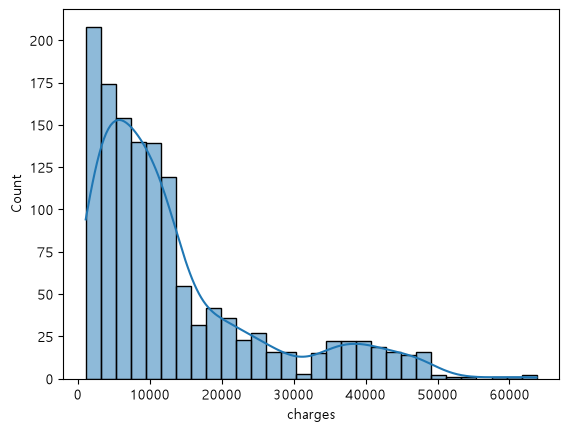

In [17]:
# charges의 분포 확인
sns.histplot(data=df,x='charges',kde=True)
print(df['charges'].skew())

왜도가 높아 정규분포에 가깝지 않음

{'sex': {0: 'female', 1: 'male'}, 'smoker': {0: 'no', 1: 'yes'}, 'region': {0: 'northeast', 1: 'northwest', 2: 'southwest', 3: 'southeast'}}


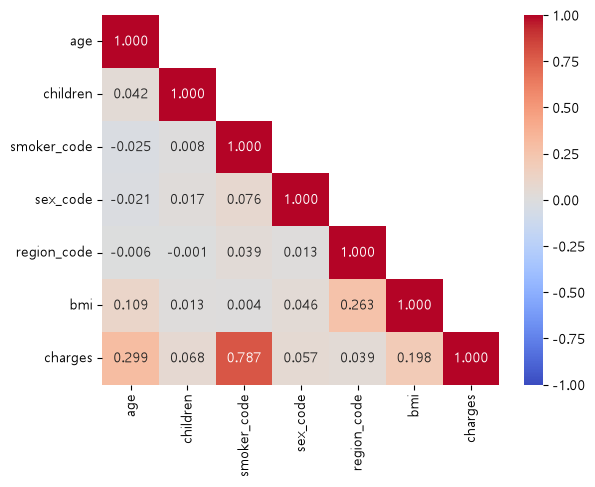

In [9]:
# charges와 다른 변수 간 상관관계 확인

# 범주형 변수 이산형으로 변환
cat_orders = {
    'sex':    ['female', 'male'],                                   # 0, 1
    'smoker': ['no', 'yes'],                                        # 0, 1
    'region': ['northeast', 'northwest', 'southwest', 'southeast'], # 0, 1, 2, 3
}

for col, order in cat_orders.items():
    df[col + '_code'] = pd.Categorical(df[col], categories=order).codes

code_labels = {col: dict(enumerate(order)) for col, order in cat_orders.items()}
print(code_labels)

df[['sex', 'sex_code', 'smoker', 'smoker_code', 'region', 'region_code']].head()
df_num=df[['age','children','smoker_code','sex_code','region_code','bmi','charges']].copy()
corr_value=df_num.corr()

mask=np.zeros((7,7))
for i,row in enumerate(mask):
    for j,k in enumerate(row):
        if i<j:
            mask[i,j]=1
g=sns.heatmap(corr_value,annot=True,fmt='.3f',vmin=-1,vmax=1,cmap='coolwarm',mask=mask)
plt.show()

상관계수 흡연여부 > 나이 > BMI 순으로 영향이 있음

In [ ]:
# 흡연, 나이, BMI에 따른 charges의 선형성 확인

---
# 3. Train / Test 데이터 분리

In [ ]:
X=df_num.drop(columns='charges')
y=df_num['charges']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=RANDOM_STATE
)

print(f'전체: {X.shape[0]}')
print(f'학습: {X_train.shape[0]}')
print(f'Test: {X_test.shape[0]}')
print(f'y_train 평균: {y_train.mean()}, y_test 평균: {y_test.mean()}')

전체: 1338
학습: 1070
Test: 268
y_train 평균: 13230.161574933645, y_test 평균: 13431.164573059703


---
# 4. 데이터 전처리


* 결측치 처리: 결측치 없음
* 범주형 데이터 처리: 이산형으로 변환

In [ ]:
# 범주형 변수 이산형으로 변환
cat_orders = {
    'sex':    ['female', 'male'],                                   # 0, 1
    'smoker': ['no', 'yes'],                                        # 0, 1
    'region': ['northeast', 'northwest', 'southwest', 'southeast'], # 0, 1, 2, 3
}

for col, order in cat_orders.items():
    df[col + '_code'] = pd.Categorical(df[col], categories=order).codes

code_labels = {col: dict(enumerate(order)) for col, order in cat_orders.items()}
print(code_labels)

df[['sex', 'sex_code', 'smoker', 'smoker_code', 'region', 'region_code']].head()
df_num=df[['age','children','smoker_code','sex_code','region_code','bmi','charges']].copy()

---
# 5. Baseline 모델 검증

In [13]:
def evaluate(name, y_true, y_pred):
    '''Return a single-row metric record.'''
    return {
        'model': name,
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


# baseline 1: always predict the training mean
baseline_mean = DummyRegressor(strategy='mean').fit(X_train, y_train)

# baseline 2: always predict the training median
baseline_median = DummyRegressor(strategy='median').fit(X_train, y_train)

# first linear fit
linear = LinearRegression().fit(X_train, y_train)

report = pd.DataFrame([
    evaluate('baseline_mean', y_train, baseline_mean.predict(X_train)),
    evaluate('baseline_median', y_train, baseline_median.predict(X_train)),
    evaluate('linear', y_train, linear.predict(X_train)),
])
print(report)

             model          rmse          mae        r2
0    baseline_mean  12076.792882  9113.794477  0.000000
1  baseline_median  12710.767059  8358.623587 -0.107746
2           linear   6065.881122  4170.537225  0.747719


* 데이터의 높은 왜도를 고려했을 때 RMSE와 MAE의 움직임 설명 가능
* R2 = 약 0.75로 변수들의 설명력 충분
* baseline 모델의 R2가 음수로서 모델의 설명력 부족 -> 개선 모델 적용 필요

---
# 6. 모델 비교

In [19]:
candidates={
    'Linear': LinearRegression(),
    "Ridge (alpha=1)":Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso (alpha=1)":Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000),
    "DecisionTree":DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest":RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting":GradientBoostingRegressor(random_state=RANDOM_STATE),
}

In [25]:
# 5-Fold 교차검증으로 모델별 CV_RMSE, CV_R2 계산 (학습 데이터만 사용)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

records = []
for name, estimator in candidates.items():
    # 규제 선형 모델은 스케일에 민감하므로 fold 내부에서 표준화
    if name.startswith(('Ridge', 'Lasso')):
        estimator = Pipeline([('scaler', StandardScaler()), ('model', estimator)])

    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring)
    record = {
        'model': name,
        'cv_rmse': -scores['test_rmse'].mean(),
        'cv_rmse_std': scores['test_rmse'].std(),
        'cv_r2': scores['test_r2'].mean(),
        'cv_r2_std': scores['test_r2'].std(),
    }
    records.append(record)
    print(f"{name:<22} RMSE {record['cv_rmse']:>9,.0f} (std: {record['cv_rmse_std']:,.0f})   "
          f"R2 {record['cv_r2']:.4f}")

report = (pd.DataFrame(records).sort_values('cv_rmse').reset_index(drop=True))

Linear                 RMSE     6,093 (std: 420)   R2 0.7435
Ridge (alpha=1)        RMSE     6,089 (std: 341)   R2 0.7435
Lasso (alpha=1)        RMSE     6,123 (std: 202)   R2 0.7392
DecisionTree           RMSE     6,637 (std: 358)   R2 0.6950
RandomForest           RMSE     4,911 (std: 395)   R2 0.8325
GradientBoosting       RMSE     4,729 (std: 430)   R2 0.8430


* GradientBoosting 모델이 가장 적합
* DecidionTree 단독 모델은 가장 부적합

---
# 7. GridSearchCV 튜닝

In [27]:
# 6장에서 가장 성능이 좋았던 GradientBoosting 모델의 하이퍼파라미터 튜닝
gb_pipe = Pipeline([("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])

gb_grid = {
    "model__n_estimators":  [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth":     [2, 3, 4],
    "model__subsample":     [0.8, 1.0],
}

# 6장과 같은 5-Fold(cv)로 탐색해 CV RMSE가 가장 낮은 조합 선택
gb_search = GridSearchCV(
    gb_pipe, gb_grid, cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=0
)
gb_search.fit(X_train, y_train)

print("총 탐색 조합 수 :", len(gb_search.cv_results_["params"]))
print("최적 하이퍼파라미터:")
for k, v in gb_search.best_params_.items():
    print(f"   {k.replace('model__',''):<15} = {v}")

before_rmse = report.loc[report["model"] == "GradientBoosting", "cv_rmse"].iloc[0]
print(f"\n튜닝 전 CV RMSE : {before_rmse:,.0f}")
print(f"튜닝 후 CV RMSE : {-gb_search.best_score_:,.0f}")

# 8장 평가에서 사용할 최종 모델
best_model = gb_search.best_estimator_

총 탐색 조합 수 : 54
최적 하이퍼파라미터:
   learning_rate   = 0.01
   max_depth       = 3
   n_estimators    = 500
   subsample       = 0.8

튜닝 전 CV RMSE : 4,729
튜닝 후 CV RMSE : 4,547


---
# 8. 모델 평가 (Test data 활용)

In [28]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name="model"):
    model.fit(X_tr, y_tr)
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    out = {
        "model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, pred_tr)),
        "Test RMSE":  np.sqrt(mean_squared_error(y_te, pred_te)),
        "Test MAE":   mean_absolute_error(y_te, pred_te),
        "Train R2":   r2_score(y_tr, pred_tr),
        "Test R2":    r2_score(y_te, pred_te),
    }
    return out, pred_te

# 범주형 변수는 4장에서 이미 숫자로 변환했으므로 전처리 없이 모델만 사용
lin_model = LinearRegression()

final_rows = []
row_lin, pred_lin = evaluate(lin_model, X_train, y_train, X_test, y_test, "LinearRegression (baseline)")
row_best, pred_best = evaluate(best_model, X_train, y_train, X_test, y_test, "Tuned best model")
final_rows += [row_lin, row_best]

final_df = pd.DataFrame(final_rows)
display(final_df.style.format({
    "Train RMSE": "{:,.0f}", "Test RMSE": "{:,.0f}", "Test MAE": "{:,.0f}",
    "Train R2": "{:.4f}", "Test R2": "{:.4f}"}))

,model,Train RMSE,Test RMSE,Test MAE,Train R2,Test R2
0,LinearRegression (baseline),"6,066","5,959","4,047",0.7477,0.7621
1,Tuned best model,"4,091","4,223","2,352",0.8852,0.8805


* Train과 Test 간 RMSE 격차가 적어 과소적합

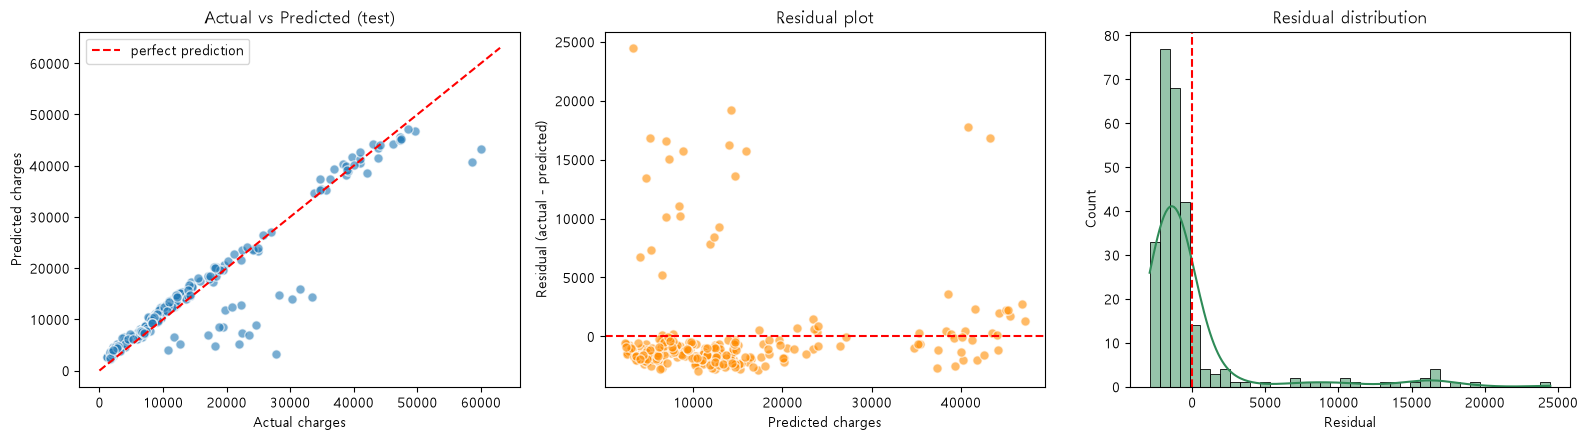

잔차 평균: -92 / 잔차 표준편차: 4,230


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) 실제 vs 예측
axes[0].scatter(y_test, pred_best, alpha=0.6, edgecolor="w", s=45)
lims = [0, max(y_test.max(), pred_best.max()) * 1.05]
axes[0].plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
axes[0].set_xlabel("Actual charges"); axes[0].set_ylabel("Predicted charges")
axes[0].set_title("Actual vs Predicted (test)"); axes[0].legend()

# (2) 잔차 플롯
resid = y_test - pred_best
axes[1].scatter(pred_best, resid, alpha=0.6, edgecolor="w", s=45, color="darkorange")
axes[1].axhline(0, color="red", ls="--", lw=1.5)
axes[1].set_xlabel("Predicted charges"); axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residual plot")

# (3) 잔차 분포
sns.histplot(resid, bins=40, kde=True, ax=axes[2], color="seagreen")
axes[2].axvline(0, color="red", ls="--")
axes[2].set_title("Residual distribution"); axes[2].set_xlabel("Residual")

plt.tight_layout(); plt.show()
print(f"잔차 평균: {resid.mean():,.0f} / 잔차 표준편차: {resid.std():,.0f}")